### Clustering for recommendation

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [68]:
# grouping the borrowings dataset by the book title

borrowings = pd.read_csv("../../../data/processed/library_borrowings.csv")

borrowings_agg = (borrowings.groupby("Title").agg(
        borrow_count=("Reader_num", "count"),
        avg_duration=("borrowing_duration", "mean"),
        category=("category", lambda x: x.mode()[0])
    ).reset_index()
)

print(borrowings_agg.shape)

borrowings_agg.head()

(132, 4)


,Title,borrow_count,avg_duration,category
0,400 EXERCICES CORRIGÉS D'ALGÈBRE AVEC RAPPELS ...,1,30.0,0
1,A FIRST COURSE IN PROBABILITY,2,15.0,2
2,ADVANCED CYBERSECURITY TECHNOLOGIES,2,18.5,3
3,ADVANCED DATA STRUCTURES: THEORY AND APPLICATIONS,1,15.0,1
4,AGILE STRATEGY MANAGEMENT : TECHNIQUES FOR CON...,2,15.0,1


In [69]:
# loading the inventory dataset and merging it with the borrowings_agg dataset

inventory = pd.read_csv("../../../data/processed/library_inventory.csv")

inventory_counts = (
    inventory
    .groupby("Title")
    .size()
    .reset_index(name="copy_count_inventory")
)

inventory_counts.head()

,Title,copy_count_inventory
0,"100 FICHES POUR BIEN DÉMARRER EN PRÉPA, 2021-2...",1
1,400 EXERCICES CORRIGÉS D'ALGÈBRE AVEC RAPPELS ...,1
2,50 [CINQUANTE]CLÉS POUR COMPRENDRE LA PHYSIQUE,2
3,8 ANS DE PROBLÈMES CORRIGÉS DE MATHÉMATIQUES P...,2
4,A FIRST COURSE IN PROBABILITY,3


In [70]:
# merging the 2 datasets

book_df = pd.merge(
    borrowings_agg,
    inventory_counts,
    on="Title",
    how="left"
)

print("missing values summary: ")
print(book_df.isna().sum())

book_df.head(10)

missing values summary: 
Title                   0
borrow_count            0
avg_duration            0
category                0
copy_count_inventory    0
dtype: int64


,Title,borrow_count,avg_duration,category,copy_count_inventory
0,400 EXERCICES CORRIGÉS D'ALGÈBRE AVEC RAPPELS ...,1,30.000000,0,1
1,A FIRST COURSE IN PROBABILITY,2,15.000000,2,3
2,ADVANCED CYBERSECURITY TECHNOLOGIES,2,18.500000,3,3
3,ADVANCED DATA STRUCTURES: THEORY AND APPLICATIONS,1,15.000000,1,3
4,AGILE STRATEGY MANAGEMENT : TECHNIQUES FOR CON...,2,15.000000,1,3
5,ALGEBRE 1 : RAPPELS DE COURS ET EXERCICES AVEC...,55,16.345455,1,135
6,ALGORITHMIQUE : COURS ET EXERCICES CORRIGÉS,4,14.000000,1,53
7,ALGORITHMIQUE ET PROGRAMMATION EN JAVA : COURS...,1,15.000000,1,6
8,ALGORITHMIQUE ET STRUCTURES DE DONNÉES STATIQU...,3,15.000000,1,4
9,ALGORITHMIQUE MODERNE ANALYSE ET COMPLEXITÉ,2,15.000000,1,62


In [71]:
#========================================================================
#---------------------------Start Clustering-----------------------------
#========================================================================

X = book_df[["borrow_count", "avg_duration", "category", "copy_count_inventory"]]

# hot encoding the category column so that it won't be treated as an ordered attribute
X = pd.get_dummies(X, columns=['category'])
print(f"Rows: {X.shape[0]}\nColumns: {X.shape[1]}")
X.head()

Rows: 132
Columns: 8


,borrow_count,avg_duration,copy_count_inventory,category_0,category_1,category_2,category_3,category_4
0,1,30.0,1,True,False,False,False,False
1,2,15.0,3,False,False,True,False,False
2,2,18.5,3,False,False,False,True,False
3,1,15.0,3,False,True,False,False,False
4,2,15.0,3,False,True,False,False,False


<div style="font-size: 30px; font-weight: bold;
            background: linear-gradient(90deg, #41ecffff, #017bf6ff); 
            -webkit-background-clip: text; 
            -webkit-text-fill-color: transparent;">
  K means
</div>

In [72]:
# scaling the dataset since thay are on high different scale

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

c:\Users\LEGION\anaconda3\envs\DM_ENV\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\LEGION\anaconda3\envs\DM_ENV\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\LEGION\anaconda3\envs\DM_ENV\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\LEGION\anaconda3\envs\DM_ENV\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarn

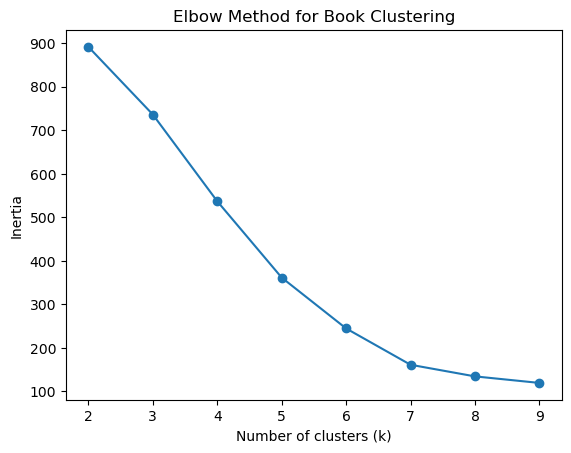

In [73]:
# deciding the number of clusters using elbow method

from sklearn.cluster import KMeans

inertia = []
k_range = range(2, 10)

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure()
plt.plot(k_range, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Book Clustering")
plt.show()

In [74]:
# we choose K = 7 as the number of clusters according to the plot
# we apply clustering
K = 7
kmeans = KMeans(n_clusters=K, random_state=42)
book_df["cluster"] = kmeans.fit_predict(X_scaled)

c:\Users\LEGION\anaconda3\envs\DM_ENV\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [75]:
# evaluate the clustering

from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, book_df["cluster"])
print("Silhouette Score:", score)

Silhouette Score: 0.69167541881156


In [76]:
# interpretation of clusters

cluster_summary = (book_df.groupby("cluster").agg(
    avg_borrow_count=("borrow_count", "mean"),
    avg_duration=("avg_duration", "mean"),
    avg_copies=("copy_count_inventory", "mean"),
    book_count=("Title", "count"))
)

print(cluster_summary)

         avg_borrow_count  avg_duration  avg_copies  book_count
cluster                                                        
0                1.333333     16.855556    2.400000          15
1                2.250000     15.297727    9.727273          44
2                1.000000     12.583333    3.166667          12
3                5.000000      9.867725  133.333333           6
4                1.318182     12.310606   11.454545          22
5                2.166667     14.856296    9.366667          30
6               55.333333     15.774346  145.000000           3


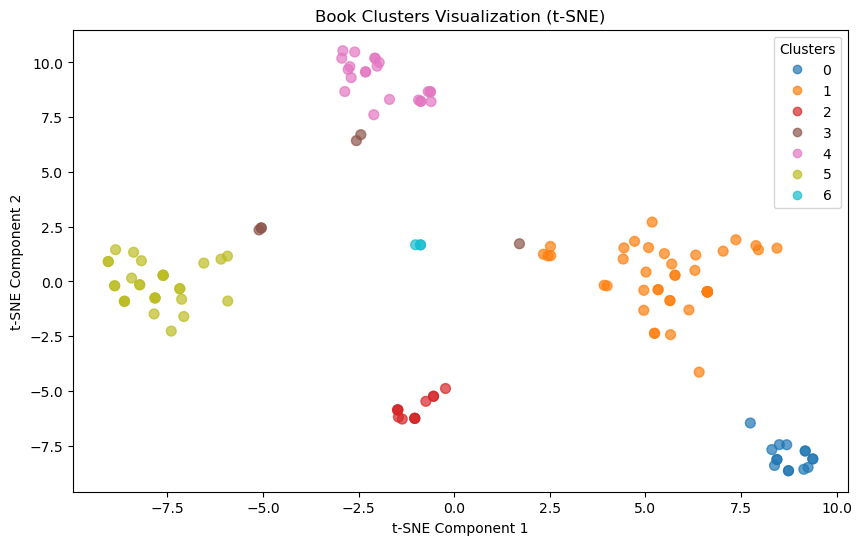

In [77]:
#========================================================================
#----------------------Visualization fo clusters-------------------------
#========================================================================


from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(10,6))
scatter = plt.scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=book_df["cluster"],
    cmap='tab10',
    s=50,
    alpha=0.7
)
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("Book Clusters Visualization (t-SNE)")
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()


<div style="font-size: 30px; font-weight: bold;
            background: linear-gradient(90deg, #41ecffff, #017bf6ff); 
            -webkit-background-clip: text; 
            -webkit-text-fill-color: transparent;">
  DBSCAN
</div>

Data dimensionality: 8
Selected minPts: 8


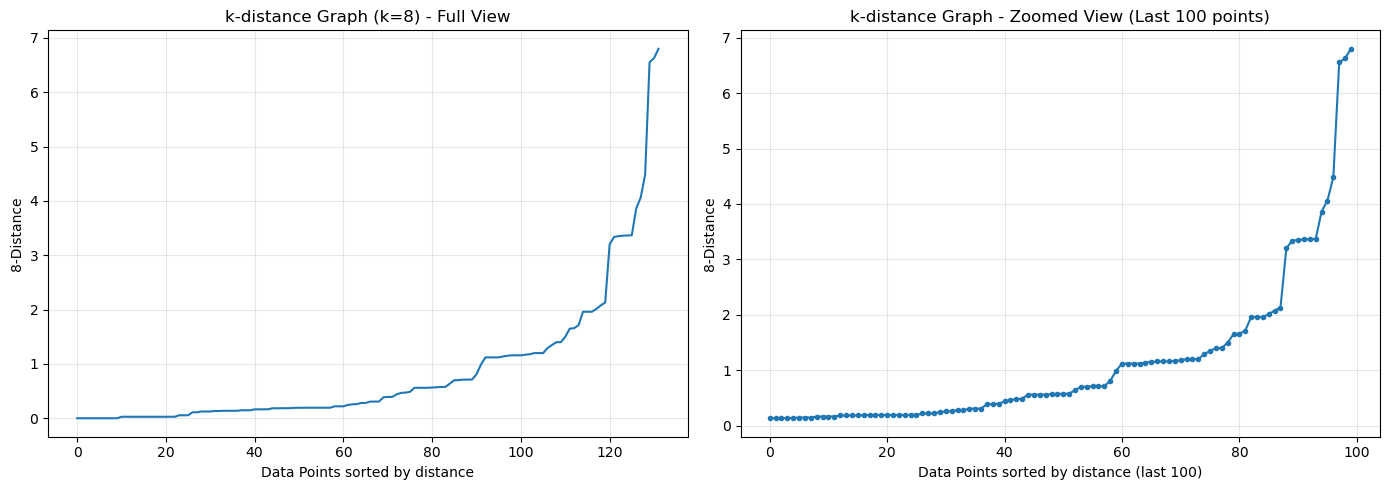

In [78]:
from sklearn.neighbors import NearestNeighbors

# Setting the value of MinPts using rule: minPts >= dimensionality
data_dimensionality = X_scaled.shape[1]
minPts = max(data_dimensionality, 5)  # Use at least 5
print(f"Data dimensionality: {data_dimensionality}")
print(f"Selected minPts: {minPts}")

# Finding optimal epsilon using k-distance graph
nbrs = NearestNeighbors(n_neighbors=minPts).fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

# Sort distances for the k-th nearest neighbor (minPts-1 index)
k_distances = np.sort(distances[:, minPts-1])

# Plot k-distance graph
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Full k-distance plot
ax1.plot(k_distances)
ax1.set_xlabel("Data Points sorted by distance")
ax1.set_ylabel(f"{minPts}-Distance")
ax1.set_title(f"k-distance Graph (k={minPts}) - Full View")
ax1.grid(True, alpha=0.3)

# Zoomed plot to find the elbow
ax2.plot(k_distances[-100:], marker='o', markersize=3)
ax2.set_xlabel("Data Points sorted by distance (last 100)")
ax2.set_ylabel(f"{minPts}-Distance")
ax2.set_title("k-distance Graph - Zoomed View (Last 100 points)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


EPSILON PARAMETER OPTIMIZATION RESULTS
 eps  n_clusters  silhouette
 0.2           5    0.165486
 0.3           5    0.263115
 0.4           5    0.376659
 0.5           5    0.399430
 0.6           5    0.469840
 0.7           5    0.478225
 0.8           5    0.540329
 0.9           5    0.540329
 1.0           5    0.540329
 1.1           5    0.551540
 1.2           6    0.640579
 1.3           6    0.654098
 1.4           6    0.654098
 1.5           6    0.677194
 1.6           5    0.654254
 1.7           5    0.654254
 1.8           5    0.658210
 1.9           5    0.656298
 2.0           5    0.661165

Best epsilon: 1.5000
  - Clusters: 6
  - Silhouette Score: 0.6772


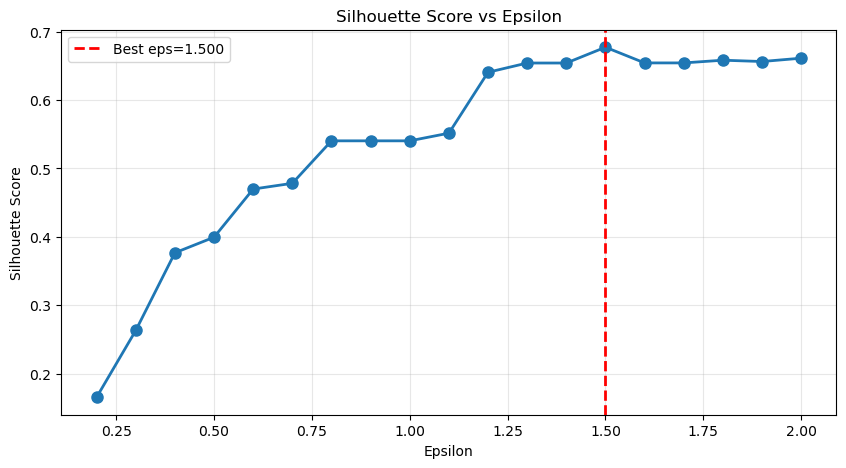

In [79]:
# Test multiple epsilon values to find the best one
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

epsilon_values = np.linspace(0.2, 2, 19)
results = []

for eps in epsilon_values:
    dbscan_temp = DBSCAN(eps=eps, min_samples=minPts)
    labels = dbscan_temp.fit_predict(X_scaled)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    noise_pct = (n_noise / len(labels)) * 100
    
    # Calculate silhouette score only if we have more than 1 cluster
    if n_clusters > 1:
        try:
            sil_score = silhouette_score(X_scaled, labels)
        except:
            sil_score = -1
    else:
        sil_score = -1
    
    results.append({
        'eps': eps,
        'n_clusters': n_clusters,
        'silhouette': sil_score
    })

results_df = pd.DataFrame(results)
print("\n" + "="*40)
print("EPSILON PARAMETER OPTIMIZATION RESULTS")
print("="*40)
print(results_df.to_string(index=False))
print("="*40)

# Find best epsilon based on highest silhouette score
valid_results = results_df[results_df['silhouette'] > -1]
if len(valid_results) > 0:
    best_idx = valid_results['silhouette'].idxmax()
    best_eps = results_df.loc[best_idx, 'eps']
    print(f"\nBest epsilon: {best_eps:.4f}")
    print(f"  - Clusters: {int(results_df.loc[best_idx, 'n_clusters'])}")
    print(f"  - Silhouette Score: {results_df.loc[best_idx, 'silhouette']:.4f}")
else:
    best_eps = 0.6
    print(f"\nUsing default epsilon: {best_eps:.4f}")

# Plot silhouette score vs epsilon
plt.figure(figsize=(10, 5))
valid_mask = results_df['silhouette'] > -1
plt.plot(results_df[valid_mask]['eps'], results_df[valid_mask]['silhouette'], marker='o', linewidth=2, markersize=8)
plt.axvline(best_eps, color='red', linestyle='--', linewidth=2, label=f'Best eps={best_eps:.3f}')
plt.xlabel('Epsilon')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Epsilon')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Use the best epsilon found
epsilon = best_eps

In [80]:
from sklearn.cluster import DBSCAN

# applying the DBSCAN algorithm

dbscan = DBSCAN(eps=epsilon, min_samples=minPts)
book_df['cluster'] = dbscan.fit_predict(X_scaled)

In [81]:
# Evaluating the DBSCAN clustering

from sklearn.metrics import silhouette_score

cluster_labels = book_df["cluster"]
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = list(cluster_labels).count(-1)
noise_pct = (n_noise / len(cluster_labels)) * 100

print("\n" + "="*60)
print("DBSCAN CLUSTERING EVALUATION")
print("="*60)
print(f"Epsilon: {epsilon:.4f}")
print(f"Min Samples (minPts): {minPts}")
print(f"\nCluster Statistics:")
print(f"  Number of clusters: {n_clusters}")
print(f"  Number of noise points (outliers): {n_noise} ({noise_pct:.1f}%)")
print(f"  Total data points: {len(cluster_labels)}")

# Calculate silhouette score
if n_clusters > 1:
    sil_score = silhouette_score(X_scaled, cluster_labels)
    print(f"\nSilhouette Score: {sil_score:.4f}")
else:
    print("\nWARNING: Less than 2 clusters found.")

print("="*60)


DBSCAN CLUSTERING EVALUATION
Epsilon: 1.5000
Min Samples (minPts): 8

Cluster Statistics:
  Number of clusters: 7
  Number of noise points (outliers): 13 (9.8%)
  Total data points: 132

Silhouette Score: 0.6772


In [82]:
# interpretation of clusters

cluster_summary = (book_df.groupby("cluster").agg(
    avg_borrow_count=("borrow_count", "mean"),
    avg_duration=("avg_duration", "mean"),
    avg_copies=("copy_count_inventory", "mean"),
    book_count=("Title", "count"))
)

print(cluster_summary)

         avg_borrow_count  avg_duration  avg_copies  book_count
cluster                                                        
-1              16.692308     15.916790   96.846154          13
 0               1.620690     14.803448    9.000000          29
 1               1.230769     15.576923    9.153846          13
 2               2.279070     14.909302    9.930233          43
 3               1.444444      7.592593   14.777778           9
 4               1.000000     11.727273    3.272727          11
 5               1.357143     15.916667    2.500000          14


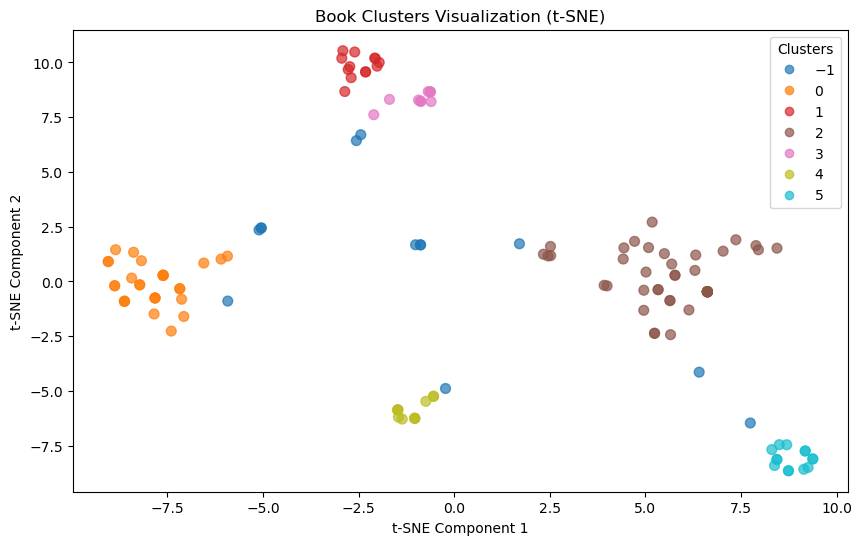

In [83]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(10,6))
scatter = plt.scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=book_df["cluster"],
    cmap='tab10',
    s=50,
    alpha=0.7
)
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("Book Clusters Visualization (t-SNE)")
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()

<div style="font-size: 30px; font-weight: bold;
            background: linear-gradient(90deg, #41ecffff, #017bf6ff); 
            -webkit-background-clip: text; 
            -webkit-text-fill-color: transparent;">
  Hierarchical Clustering (Agglomerative)
</div>


HIERARCHICAL CLUSTERING - LINKAGE METHODS COMPARISON

Best configuration:
  Linkage method: ward
  Number of clusters: 8
  Silhouette Score: 0.7023


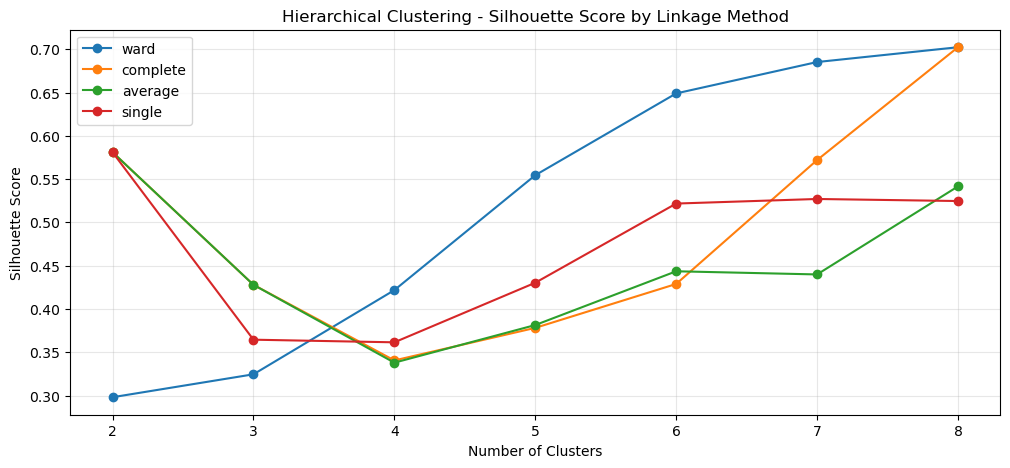

In [84]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import silhouette_score

# Test different linkage methods
linkage_methods = ['ward', 'complete', 'average', 'single']
hc_results = []

for method in linkage_methods:
    Z = linkage(X_scaled, method=method)
    
    # Try different number of clusters (2-8)
    for n_clust in range(2, 9):
        labels = fcluster(Z, n_clust, criterion='maxclust') - 1
        sil_score = silhouette_score(X_scaled, labels)
        hc_results.append({
            'linkage': method,
            'n_clusters': n_clust,
            'silhouette': sil_score
        })

hc_df = pd.DataFrame(hc_results)
print("\n" + "="*60)
print("HIERARCHICAL CLUSTERING - LINKAGE METHODS COMPARISON")
print("="*60)

# Find best combination
best_hc_idx = hc_df['silhouette'].idxmax()
best_linkage = hc_df.loc[best_hc_idx, 'linkage']
best_n_clusters_hc = int(hc_df.loc[best_hc_idx, 'n_clusters'])
best_sil_hc = hc_df.loc[best_hc_idx, 'silhouette']

print(f"\nBest configuration:")
print(f"  Linkage method: {best_linkage}")
print(f"  Number of clusters: {best_n_clusters_hc}")
print(f"  Silhouette Score: {best_sil_hc:.4f}")

# Plot comparison
plt.figure(figsize=(12, 5))
for method in linkage_methods:
    method_data = hc_df[hc_df['linkage'] == method]
    plt.plot(method_data['n_clusters'], method_data['silhouette'], marker='o', label=method)

plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Hierarchical Clustering - Silhouette Score by Linkage Method')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [85]:
# Apply hierarchical clustering with best parameters
Z = linkage(X_scaled, method=best_linkage)
hc_labels = fcluster(Z, best_n_clusters_hc, criterion='maxclust') - 1
book_df['hc_cluster'] = hc_labels

# Evaluate
hc_sil_score = silhouette_score(X_scaled, hc_labels)

print("\n" + "="*40)
print("HIERARCHICAL CLUSTERING EVALUATION")
print("="*40)
print(f"Linkage method: {best_linkage}")
print(f"Number of clusters: {best_n_clusters_hc}")
print(f"Silhouette Score: {hc_sil_score:.4f}")
print("="*40)


HIERARCHICAL CLUSTERING EVALUATION
Linkage method: ward
Number of clusters: 8
Silhouette Score: 0.7023


In [86]:
# Cluster interpretation
hc_summary = (book_df.groupby("hc_cluster").agg(
    avg_borrow_count=("borrow_count", "mean"),
    avg_duration=("avg_duration", "mean"),
    avg_copies=("copy_count_inventory", "mean"),
    book_count=("Title", "count"))
)

print(hc_summary)

            avg_borrow_count  avg_duration  avg_copies  book_count
hc_cluster                                                        
0                   2.166667     14.856296    9.366667          30
1                   1.000000     12.583333    3.166667          12
2                   4.200000      8.885714  134.000000           5
3                   1.318182     12.310606   11.454545          22
4                  55.333333     15.774346  145.000000           3
5                   2.431818     14.906313   12.659091          44
6                   1.357143     15.916667    2.500000          14
7                   1.000000     31.000000    1.000000           2


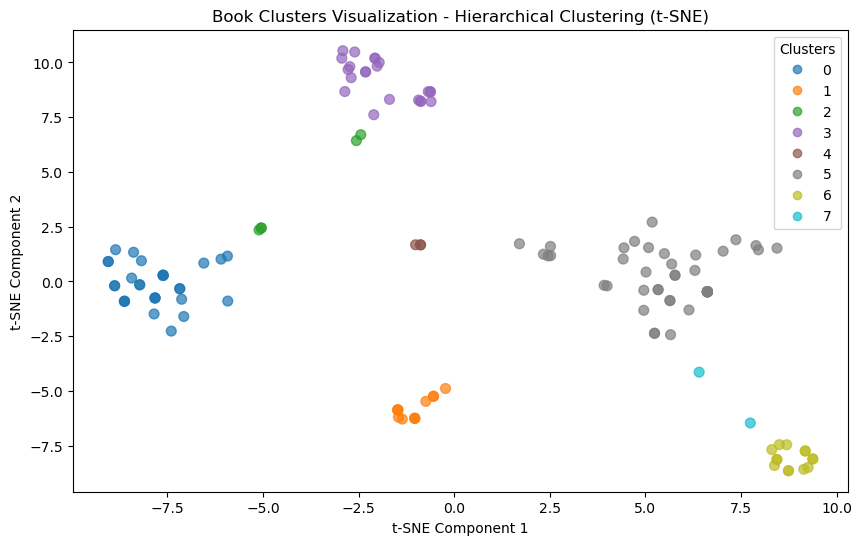

In [87]:
# Visualization
tsne_hc = TSNE(n_components=2, random_state=42)
X_tsne_hc = tsne_hc.fit_transform(X_scaled)

plt.figure(figsize=(10,6))
scatter = plt.scatter(
    X_tsne_hc[:, 0], X_tsne_hc[:, 1],
    c=book_df["hc_cluster"],
    cmap='tab10',
    s=50,
    alpha=0.7
)
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("Book Clusters Visualization - Hierarchical Clustering (t-SNE)")
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()

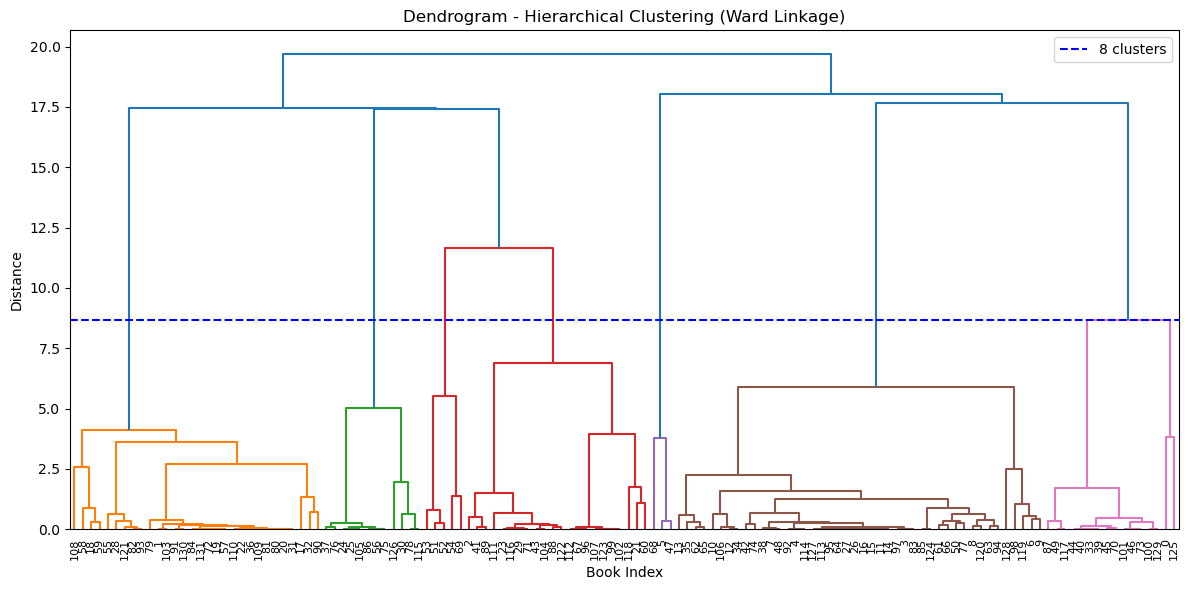

In [88]:
# Dendrogram visualization
from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(12, 6))
dendrogram(Z, leaf_rotation=90, leaf_font_size=8)
plt.title(f'Dendrogram - Hierarchical Clustering ({best_linkage.capitalize()} Linkage)')
plt.xlabel('Book Index')
plt.ylabel('Distance')
plt.axhline(y=Z[-best_n_clusters_hc+1, 2], color='blue', linestyle='--', label=f'{best_n_clusters_hc} clusters')
plt.legend()
plt.tight_layout()
plt.show()